In [1]:
import ast
from collections import Counter

import numpy as np
import optuna
import pandas as pd
from pathlib import Path

In [2]:
data_root = Path('/home/ubuntu/data/v0_6')
ref_root = Path('/home/ubuntu/data/reference_data')
hpo_output_dir = data_root / 'hpo'
study = optuna.load_study(                                                
  study_name='biojepa_v0_6_hpo_v14_phase1',
  storage=f'sqlite:///{hpo_output_dir / "biojepa_v0_6_hpo_v14_phase1"}.db'
)

In [3]:
for trial in study.trials:
    state = trial.state.name
    reason = trial.user_attrs.get('fail_reason', 'N/A')
    params = {k: trial.params.get(k, '?') for k in ['embed_dim', 'n_layer', 'heads']}
    print(f'Trial {trial.number}: {state} | D={params["embed_dim"]} L={params["n_layer"]} H={params["heads"]} | {reason}')

states = Counter(t.state.name for t in study.trials)
reasons = Counter(t.user_attrs.get('fail_reason', 'N/A') for t in study.trials if t.state.name
!= 'COMPLETE')
print(f'\nState counts: {dict(states)}')
print(f'Fail reasons: {dict(reasons)}')

Trial 0: COMPLETE | D=256 L=6 H=4 | N/A
Trial 1: COMPLETE | D=256 L=6 H=4 | N/A
Trial 2: COMPLETE | D=256 L=6 H=4 | N/A
Trial 3: COMPLETE | D=256 L=6 H=4 | N/A
Trial 4: COMPLETE | D=256 L=6 H=4 | N/A
Trial 5: COMPLETE | D=256 L=6 H=4 | N/A
Trial 6: PRUNED | D=256 L=6 H=4 | N/A
Trial 7: PRUNED | D=256 L=6 H=4 | N/A
Trial 8: COMPLETE | D=256 L=6 H=4 | N/A
Trial 9: COMPLETE | D=256 L=6 H=4 | N/A
Trial 10: COMPLETE | D=256 L=6 H=4 | N/A
Trial 11: COMPLETE | D=256 L=6 H=4 | N/A
Trial 12: PRUNED | D=256 L=6 H=4 | N/A
Trial 13: PRUNED | D=256 L=6 H=4 | N/A
Trial 14: COMPLETE | D=256 L=6 H=4 | N/A
Trial 15: PRUNED | D=256 L=6 H=4 | N/A
Trial 16: COMPLETE | D=256 L=6 H=4 | N/A
Trial 17: FAIL | D=256 L=6 H=4 | N/A

State counts: {'COMPLETE': 12, 'PRUNED': 5, 'FAIL': 1}
Fail reasons: {'N/A': 6}


In [4]:
for trial in study.trials[:]:
    print(f'Trial {trial.number}: user_attrs={trial.user_attrs}, system_attrs={trial.system_attrs}')

Trial 0: user_attrs={'eval_10000': {'pert_auroc': 0.5233, 'eff_dim_90': 16, 'dead_dims': 0, 'recon_pearson': 0.96, 'invariance_ratio': 0.3, 'kegg_silhouette': -0.0474, 'cell_type_acc': 0.8999, 'essential_auroc': 0.6389, 'consistency_ratio': 0.9266}, 'eval_15000': {'pert_auroc': 0.5471, 'eff_dim_90': 17, 'dead_dims': 0, 'recon_pearson': 0.9556, 'invariance_ratio': 0.25, 'kegg_silhouette': -0.0503, 'essential_auroc': 0.6392, 'consistency_ratio': 0.7444}, 'eval_20000': {'pert_auroc': 0.5754, 'eff_dim_90': 15, 'dead_dims': 0, 'recon_pearson': 0.9644, 'invariance_ratio': 0.32, 'kegg_silhouette': -0.0494, 'cell_type_acc': 0.8929, 'essential_auroc': 0.6356, 'consistency_ratio': 1.0046}, 'eval_25000': {'pert_auroc': 0.5446, 'eff_dim_90': 15, 'dead_dims': 0, 'recon_pearson': 0.9545, 'invariance_ratio': 0.1852, 'kegg_silhouette': -0.0506, 'essential_auroc': 0.6367, 'consistency_ratio': 0.717}, 'eval_30000': {'pert_auroc': 0.564, 'eff_dim_90': 16, 'dead_dims': 0, 'recon_pearson': 0.9456, 'invaria

In [5]:
importances = optuna.importance.get_param_importances(study)                     
importances     

{'vicreg_weight': np.float64(0.2829073925561531),
 'mask_ratio': np.float64(0.22872718478068083),
 'ema_momentum': np.float64(0.22716850234196834),
 'film_linear_multiple': np.float64(0.13809313737405035),
 'lr': np.float64(0.08986675358116782),
 'gaussian_scale': np.float64(0.03323702936597959),
 'n_layer': np.float64(0.0),
 'heads': np.float64(0.0),
 'embed_dim': np.float64(0.0)}

/tmp/ipykernel_137285/2210069751.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study)
/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/optuna/visualization/matplotlib/_slice.py:146: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim[0], xlim[1])


array([<Axes: xlabel='ema_momentum', ylabel='Objective Value'>,
       <Axes: xlabel='embed_dim'>, <Axes: xlabel='film_linear_multiple'>,
       <Axes: xlabel='gaussian_scale'>, <Axes: xlabel='heads'>,
       <Axes: xlabel='lr'>, <Axes: xlabel='mask_ratio'>,
       <Axes: xlabel='n_layer'>, <Axes: xlabel='vicreg_weight'>],
      dtype=object)

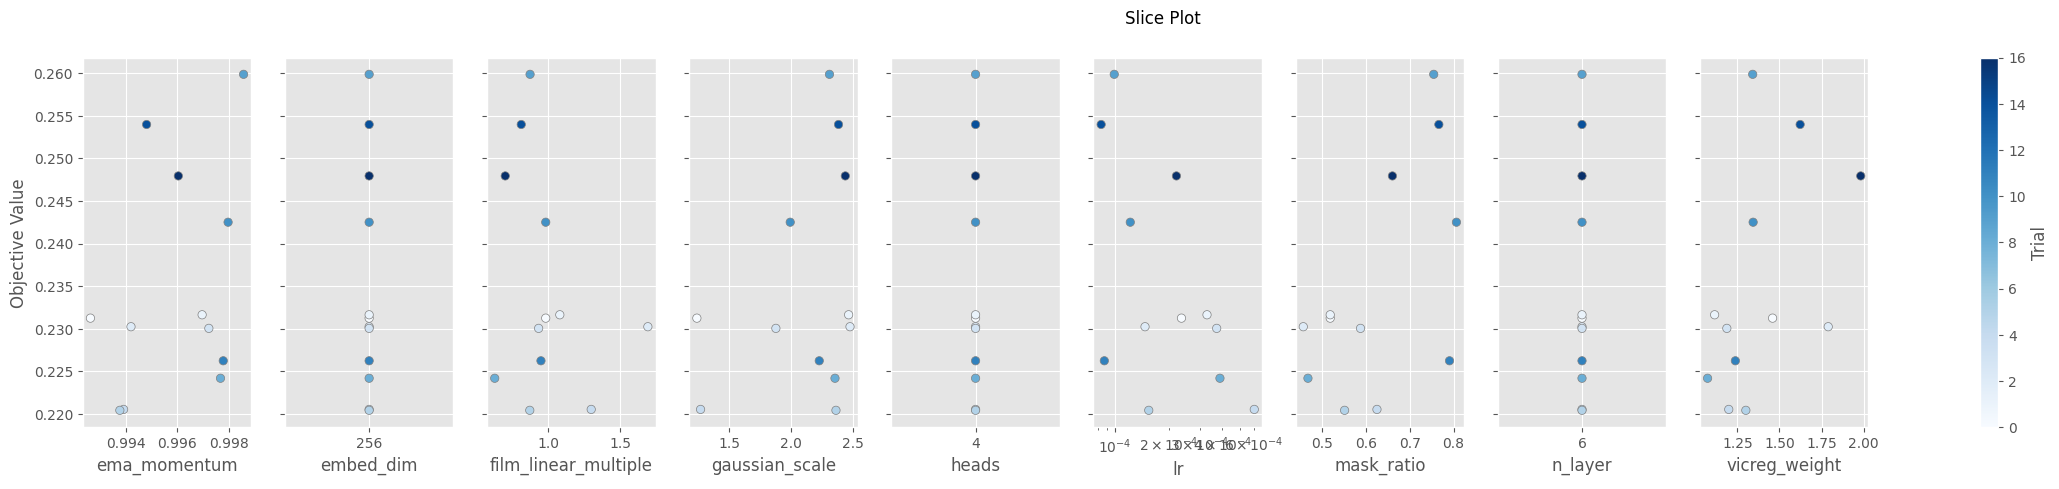

In [6]:
optuna.visualization.matplotlib.plot_slice(study)   

In [7]:
df = study.trials_dataframe()
completed = df[df['value'].notna()]
k = max(5, len(completed) // 5)
top_k = completed.nlargest(k, 'value')

continuous_params = [c for c in completed.columns if c.startswith('params_') ]
centroid = top_k[continuous_params].median()
centroid_std = top_k[continuous_params].std()

top_k[['number', 'value'] + continuous_params]

,number,value,params_ema_momentum,params_embed_dim,params_film_linear_multiple,params_gaussian_scale,params_heads,params_lr,params_mask_ratio,params_n_layer,params_vicreg_weight
9,9,0.259851,0.998565,256,0.872836,2.309454,4,0.000099,0.754735,6,1.341311
14,14,0.253966,0.994814,256,0.811482,2.382542,4,0.000084,0.766465,6,1.622922
16,16,0.247930,0.996042,256,0.700288,2.437447,4,0.000221,0.660200,6,1.982442
10,10,0.242499,0.997966,256,0.981584,1.992331,4,0.000122,0.806701,6,1.343901
15,15,0.240561,0.993185,256,0.700291,2.499106,4,0.000082,0.784834,6,1.660110


In [8]:
centroid, centroid_std

(params_ema_momentum              0.996042
 params_embed_dim               256.000000
 params_film_linear_multiple      0.811482
 params_gaussian_scale            2.382542
 params_heads                     4.000000
 params_lr                        0.000099
 params_mask_ratio                0.766465
 params_n_layer                   6.000000
 params_vicreg_weight             1.622922
 dtype: float64,
 params_ema_momentum            0.002220
 params_embed_dim               0.000000
 params_film_linear_multiple    0.119802
 params_gaussian_scale          0.198226
 params_heads                   0.000000
 params_lr                      0.000058
 params_mask_ratio              0.056304
 params_n_layer                 0.000000
 params_vicreg_weight           0.265716
 dtype: float64)

In [9]:
df.to_csv(hpo_output_dir / f'biojepa_v0_6_hpo_v14_results.csv', index=False)

In [10]:
WEIGHTS = {
    'pert': 0.15, 'batch_inv': 0.15, 'recon': 0.15, 'health': 0.15,
    'pathway': 0.20, 'essential': 0.10, 'consist': 0.10,
}

completed = [t for t in study.trials if t.state.name == 'COMPLETE']

rows = []
for t in completed:
    final = t.user_attrs.get('eval_final', {})
    if isinstance(final, str):
        final = ast.literal_eval(final)

    eff_dim_pct = final.get('eff_dim_90', 128) / 256
    dim_score = max(0, min(1, (eff_dim_pct - 0.3) / 0.5))
    dead_score = max(0, 1 - (final.get('dead_dims', 0) / 256) / 0.02)
    kegg_sil = final.get('kegg_silhouette', -0.05)
    consist_ratio = final.get('consistency_ratio', 1.0)

    norm = {
        'pert': max(0, (final.get('pert_auroc', 0.5) - 0.5) * 2),
        'batch_inv': min(1.0, final.get('invariance_ratio', 0) / 5.0),
        'recon': final.get('recon_pearson', 0),
        'health': 0.7 * dim_score + 0.3 * dead_score,
        'pathway': max(0, min(1, (kegg_sil + 0.05) / 0.15)),
        'essential': max(0, (final.get('essential_auroc', 0.5) - 0.5) * 2),
        'consist': max(0, min(1, (consist_ratio - 1.0) / 1.0)),
    }

    row = {'trial': t.number, 'composite': t.value, 'heads': t.params.get('heads', '?')}
    for k in WEIGHTS:
        row[f'{k}_norm'] = round(norm[k], 4)
        row[f'{k}_wtd'] = round(WEIGHTS[k] * norm[k], 4)
    rows.append(row)

decomp = pd.DataFrame(rows).set_index('trial').sort_values('composite', ascending=False)
wtd_cols = [c for c in decomp.columns if c.endswith('_wtd')]
decomp[['composite', 'heads'] + wtd_cols]

,composite,heads,pert_wtd,batch_inv_wtd,recon_wtd,health_wtd,pathway_wtd,essential_wtd,consist_wtd
trial,,,,,,,,,
9,0.259851,4,0.0079,0.0060,0.1473,0.045,0.000,0.0302,0.0235
14,0.253966,4,0.0126,0.0068,0.1460,0.045,0.000,0.0315,0.0121
16,0.247930,4,0.0134,0.0105,0.1465,0.045,0.000,0.0321,0.0004
10,0.242499,4,0.0022,0.0090,0.1472,0.045,0.000,0.0391,0.0000
1,0.231640,4,0.0063,0.0043,0.1442,0.045,0.000,0.0289,0.0030
0,0.231245,4,0.0077,0.0072,0.1434,0.045,0.000,0.0279,0.0000
2,0.230239,4,0.0120,0.0060,0.1432,0.045,0.000,0.0238,0.0002
3,0.230046,4,0.0082,0.0062,0.1456,0.045,0.000,0.0243,0.0008
11,0.226243,4,0.0013,0.0090,0.1465,0.045,0.004,0.0202,0.0002


In [11]:
wtd_df = decomp[wtd_cols]
summary = pd.DataFrame({
    'weight': {c.replace('_wtd', ''): WEIGHTS[c.replace('_wtd', '')] for c in wtd_cols},
    'mean_contribution': wtd_df.mean(),
    'std_contribution': wtd_df.std(),
    'range': wtd_df.max() - wtd_df.min(),
}).rename(index=lambda x: x.replace('_wtd', ''))
summary.sort_values('range', ascending=False)

,weight,mean_contribution,std_contribution,range
consist,NaN,0.003350,7.222880e-03,0.0235
essential,NaN,0.027658,5.255726e-03,0.0189
pert,NaN,0.006350,4.705413e-03,0.0131
batch_inv,NaN,0.007033,1.930301e-03,0.0066
recon,NaN,0.145183,1.493521e-03,0.0041
pathway,NaN,0.000333,1.154701e-03,0.0040
health,NaN,0.045000,7.247438e-18,0.0000
batch_inv,0.15,NaN,NaN,NaN
consist,0.10,NaN,NaN,NaN
essential,0.10,NaN,NaN,NaN


In [12]:
checkpoint_keys = sorted([k for k in completed[0].user_attrs if k.startswith('eval_')], key=lambda x: int(x.split('_')[1]) if x != 'eval_final' else 999999)

inv_rows = []
for t in completed:
    for ck in checkpoint_keys:
        ev = t.user_attrs.get(ck, {})
        if isinstance(ev, str):
            ev = ast.literal_eval(ev)
        if not ev:
            continue
        step = 999999 if ck == 'eval_final' else int(ck.split('_')[1])
        inv_rows.append({'trial': t.number, 'step': step, 'invariance_ratio': ev.get('invariance_ratio', np.nan)})

inv_df = pd.DataFrame(inv_rows).pivot(index='trial', columns='step', values='invariance_ratio')
inv_df.columns = [f'step_{c}' if c != 999999 else 'final' for c in inv_df.columns]
inv_df['composite'] = decomp['composite']
inv_df.sort_values('composite', ascending=False)

,step_5000,step_10000,step_15000,step_20000,step_25000,step_30000,final,composite
trial,,,,,,,,
9,0.2000,0.2963,0.2222,0.3214,0.2069,0.2000,0.2000,0.259851
14,0.2414,0.3333,0.3333,0.3333,0.4286,0.2258,0.2258,0.253966
16,0.2692,0.5882,0.3333,0.3750,0.2727,0.3500,0.3500,0.247930
10,0.2222,0.3478,0.1875,0.2414,0.4074,0.3000,0.3000,0.242499
1,0.3684,0.1923,0.1290,0.2857,0.1923,0.1429,0.1429,0.231640
0,0.3200,0.3000,0.2500,0.3200,0.1852,0.2400,0.2400,0.231245
2,0.3000,0.2609,0.3200,0.4118,0.2143,0.2000,0.2000,0.230239
3,0.3043,0.1429,0.1724,0.1515,0.1923,0.2059,0.2059,0.230046
11,0.2000,0.3500,0.1923,0.3182,0.2692,0.3000,0.3000,0.226243


# Metric trajectories across checkpoints

In [13]:
metrics_to_track = ['pert_auroc', 'essential_auroc', 'recon_pearson', 'consistency_ratio', 'kegg_silhouette']

traj_rows = []
for t in completed:
    for ck in checkpoint_keys:
        ev = t.user_attrs.get(ck, {})
        if isinstance(ev, str):
            ev = ast.literal_eval(ev)
        if not ev:
            continue
        step = 'final' if ck == 'eval_final' else int(ck.split('_')[1])
        for m in metrics_to_track:
            if m in ev:
                traj_rows.append({'trial': t.number, 'step': step, 'metric': m, 'value': ev[m]})

traj_df = pd.DataFrame(traj_rows)

for m in metrics_to_track:
    mdf = traj_df[traj_df['metric'] == m]
    if mdf.empty:
        continue
    pivot = mdf.pivot(index='trial', columns='step', values='value')
    step_cols = [c for c in pivot.columns if c != 'final']
    pivot = pivot[sorted(step_cols) + (['final'] if 'final' in pivot.columns else [])]
    peak_col = pivot.idxmax(axis=1) if m != 'kegg_silhouette' else pivot.idxmax(axis=1)
    pivot['peak_at'] = peak_col
    print(f'\n=== {m} ===')
    display(pivot)


=== pert_auroc ===


step,5000,10000,15000,20000,25000,30000,final,peak_at
trial,,,,,,,,
0,0.5315,0.5233,0.5471,0.5754,0.5446,0.5640,0.5258,20000
1,0.5470,0.5382,0.5057,0.5514,0.5172,0.5390,0.5209,20000
2,0.5174,0.4987,0.5083,0.5422,0.5566,0.5407,0.5399,25000
3,0.5194,0.5122,0.5047,0.5588,0.5234,0.5173,0.5272,20000
4,0.5111,0.5224,0.5040,0.6183,0.5846,0.5226,0.5009,20000
5,0.4983,0.5232,0.5096,0.5422,0.4877,0.5028,0.5055,20000
8,0.4936,0.5354,0.4873,0.5696,0.5090,0.4921,0.5091,20000
9,0.5610,0.5225,0.5166,0.5314,0.5179,0.5169,0.5262,5000
10,0.5283,0.5405,0.4978,0.5141,0.5062,0.5166,0.5073,10000



=== essential_auroc ===


step,5000,10000,15000,20000,25000,30000,final,peak_at
trial,,,,,,,,
0,0.6510,0.6389,0.6392,0.6356,0.6367,0.6416,0.6396,5000
1,0.6289,0.6268,0.6301,0.6360,0.6362,0.6410,0.6446,final
2,0.6411,0.6266,0.6109,0.6166,0.6176,0.6257,0.6191,5000
3,0.6226,0.6101,0.6267,0.6275,0.6224,0.6182,0.6213,20000
4,0.6725,0.6513,0.6418,0.6331,0.6248,0.6274,0.6175,5000
5,0.6447,0.6254,0.6121,0.6129,0.6113,0.6118,0.6104,5000
8,0.6384,0.6365,0.6379,0.6422,0.6424,0.6462,0.6414,30000
9,0.6565,0.6463,0.6416,0.6469,0.6485,0.6497,0.6511,5000
10,0.7033,0.6917,0.6929,0.6949,0.6962,0.6955,0.6957,5000



=== recon_pearson ===


step,5000,10000,15000,20000,25000,30000,final,peak_at
trial,,,,,,,,
0,0.9646,0.9600,0.9556,0.9644,0.9545,0.9456,0.9559,5000
1,0.9537,0.9788,0.9744,0.9682,0.9816,0.9657,0.9613,25000
2,0.9362,0.9385,0.9457,0.9436,0.9528,0.9737,0.9550,30000
3,0.9661,0.9672,0.9625,0.9638,0.9694,0.9679,0.9709,final
4,0.9671,0.9794,0.9536,0.9626,0.9615,0.9609,0.9605,10000
5,0.9712,0.9607,0.9693,0.9733,0.9625,0.9666,0.9596,20000
8,0.9613,0.9635,0.9607,0.9536,0.9650,0.9731,0.9621,30000
9,0.9667,0.9791,0.9820,0.9834,0.9792,0.9613,0.9819,20000
10,0.9797,0.9765,0.9773,0.9840,0.9850,0.9819,0.9812,25000



=== consistency_ratio ===


step,5000,10000,15000,20000,25000,30000,final,peak_at
trial,,,,,,,,
0,1.0020,0.9266,0.7444,1.0046,0.7170,1.0016,0.9980,20000
1,0.9944,1.0127,1.0025,1.0222,1.0064,1.0263,1.0297,final
2,1.1727,1.0059,1.0004,0.9973,0.7638,0.9992,1.0021,5000
3,0.8540,0.8469,1.0194,1.0304,0.9978,1.1723,1.0083,30000
4,0.9801,1.0042,0.9951,0.8874,1.0207,1.0001,0.9993,25000
5,1.0536,2.4657,1.0255,0.9520,0.8827,1.0079,0.9720,10000
8,0.9796,1.0050,0.8059,0.8383,0.8262,0.6663,0.7143,10000
9,0.7464,0.9980,1.0304,0.9710,1.0094,1.0343,1.2349,final
10,1.0292,0.9529,0.9920,0.7806,1.0056,1.1233,0.9896,30000



=== kegg_silhouette ===


step,5000,10000,15000,20000,25000,30000,final,peak_at
trial,,,,,,,,
0,-0.0486,-0.0474,-0.0503,-0.0494,-0.0506,-0.0504,-0.0504,10000
1,-0.0760,-0.0802,-0.0599,-0.0597,-0.0629,-0.0631,-0.0631,20000
2,-0.0532,-0.0522,-0.0543,-0.0547,-0.0545,-0.0544,-0.0544,10000
3,-0.0755,-0.0642,-0.0667,-0.0569,-0.0583,-0.0583,-0.0583,20000
4,-0.0672,-0.0801,-0.0779,-0.0865,-0.0896,-0.0894,-0.0894,5000
5,-0.0490,-0.0500,-0.0496,-0.0508,-0.0528,-0.0529,-0.0529,5000
8,-0.0743,-0.0805,-0.0648,-0.0624,-0.0645,-0.0644,-0.0644,20000
9,-0.0519,-0.0553,-0.0546,-0.0551,-0.0552,-0.0550,-0.0550,5000
10,-0.0604,-0.0543,-0.0544,-0.0562,-0.0566,-0.0567,-0.0567,10000


# Reweighted ranking (post-hoc)

In [14]:
def reweight_trials(completed_trials, custom_weights, embed_dim=256):
    '''Recompute composite scores with custom weights. Weights are auto-normalized to sum to 1.'''
    w_sum = sum(custom_weights.values())
    w_norm = {k: v / w_sum for k, v in custom_weights.items()}

    rows = []
    for t in completed_trials:
        final = t.user_attrs.get('eval_final', {})
        if isinstance(final, str):
            final = ast.literal_eval(final)

        eff_dim_pct = final.get('eff_dim_90', embed_dim // 2) / embed_dim
        dim_score = max(0, min(1, (eff_dim_pct - 0.3) / 0.5))
        dead_score = max(0, 1 - (final.get('dead_dims', 0) / embed_dim) / 0.02)

        all_norm = {
            'pert': max(0, (final.get('pert_auroc', 0.5) - 0.5) * 2),
            'batch_inv': min(1.0, final.get('invariance_ratio', 0) / 5.0),
            'recon': final.get('recon_pearson', 0),
            'health': 0.7 * dim_score + 0.3 * dead_score,
            'pathway': max(0, min(1, (final.get('kegg_silhouette', -0.05) + 0.05) / 0.15)),
            'essential': max(0, (final.get('essential_auroc', 0.5) - 0.5) * 2),
            'consist': max(0, min(1, (final.get('consistency_ratio', 1.0) - 1.0) / 1.0)),
        }

        score = sum(w_norm.get(k, 0) * all_norm[k] for k in all_norm)
        row = {
            'trial': t.number, 'score': round(score, 4),
            'lr': f'{t.params.get("lr", 0):.1e}', 'ema': round(t.params.get('ema_momentum', 0), 4),
            'gaussian': round(t.params.get('gaussian_scale', 0), 2),
            'vicreg': round(t.params.get('vicreg_weight', 0), 2),
            'mask': round(t.params.get('mask_ratio', 0), 2),
            'film': round(t.params.get('film_linear_multiple', 0), 2),
            'pert': round(final.get('pert_auroc', 0), 4),
            'essential': round(final.get('essential_auroc', 0), 4),
            'recon': round(final.get('recon_pearson', 0), 4),
            'pathway': round(final.get('kegg_silhouette', 0), 4),
            'consist': round(final.get('consistency_ratio', 0), 4),
            'batch_inv': round(final.get('invariance_ratio', 0), 4),
        }
        rows.append(row)

    return pd.DataFrame(rows).set_index('trial').sort_values('score', ascending=False)


# Weight schemes to compare
schemes = {
    'original': {'pert': 0.15, 'batch_inv': 0.15, 'recon': 0.15, 'health': 0.15, 'pathway': 0.20, 'essential': 0.10, 'consist': 0.10},
    'discriminative': {'pert': 0.30, 'essential': 0.30, 'consist': 0.15, 'batch_inv': 0.10, 'recon': 0.10, 'health': 0.05},
    'bio_signal': {'pert': 0.35, 'essential': 0.35, 'pathway': 0.10, 'consist': 0.10, 'recon': 0.10},
}

completed = [t for t in study.trials if t.state.name == 'COMPLETE']
for name, weights in schemes.items():
    print(f'\n=== {name} ===')
    w_sum = sum(weights.values())
    print({k: round(v / w_sum, 2) for k, v in weights.items()})
    display(reweight_trials(completed, weights))


=== original ===
{'pert': 0.15, 'batch_inv': 0.15, 'recon': 0.15, 'health': 0.15, 'pathway': 0.2, 'essential': 0.1, 'consist': 0.1}


,score,lr,ema,gaussian,vicreg,mask,film,pert,essential,recon,pathway,consist,batch_inv
trial,,,,,,,,,,,,,
9,0.2599,9.9e-05,0.9986,2.31,1.34,0.75,0.87,0.5262,0.6511,0.9819,-0.0550,1.2349,0.2000
14,0.2540,8.4e-05,0.9948,2.38,1.62,0.77,0.81,0.5421,0.6573,0.9736,-0.0515,1.1208,0.2258
16,0.2479,2.2e-04,0.9960,2.44,1.98,0.66,0.70,0.5448,0.6604,0.9769,-0.0580,1.0038,0.3500
10,0.2425,1.2e-04,0.9980,1.99,1.34,0.81,0.98,0.5073,0.6957,0.9812,-0.0567,0.9896,0.3000
1,0.2316,3.3e-04,0.9970,2.46,1.12,0.52,1.08,0.5209,0.6446,0.9613,-0.0631,1.0297,0.1429
0,0.2312,2.4e-04,0.9926,1.24,1.46,0.52,0.98,0.5258,0.6396,0.9559,-0.0504,0.9980,0.2400
2,0.2303,1.5e-04,0.9942,2.48,1.79,0.46,1.69,0.5399,0.6191,0.9550,-0.0544,1.0021,0.2000
3,0.2301,3.7e-04,0.9972,1.88,1.19,0.59,0.93,0.5272,0.6213,0.9709,-0.0583,1.0083,0.2059
11,0.2262,8.7e-05,0.9978,2.23,1.24,0.79,0.95,0.5042,0.6012,0.9767,-0.0470,1.0018,0.3000



=== discriminative ===
{'pert': 0.3, 'essential': 0.3, 'consist': 0.15, 'batch_inv': 0.1, 'recon': 0.1, 'health': 0.05}


,score,lr,ema,gaussian,vicreg,mask,film,pert,essential,recon,pathway,consist,batch_inv
trial,,,,,,,,,,,,,
9,0.2588,9.9e-05,0.9986,2.31,1.34,0.75,0.87,0.5262,0.6511,0.9819,-0.0550,1.2349,0.2000
14,0.2546,8.4e-05,0.9948,2.38,1.62,0.77,0.81,0.5421,0.6573,0.9736,-0.0515,1.1208,0.2258
16,0.2434,2.2e-04,0.9960,2.44,1.98,0.66,0.70,0.5448,0.6604,0.9769,-0.0580,1.0038,0.3500
10,0.2409,1.2e-04,0.9980,1.99,1.34,0.81,0.98,0.5073,0.6957,0.9812,-0.0567,0.9896,0.3000
1,0.2177,3.3e-04,0.9970,2.46,1.12,0.52,1.08,0.5209,0.6446,0.9613,-0.0631,1.0297,0.1429
0,0.2146,2.4e-04,0.9926,1.24,1.46,0.52,0.98,0.5258,0.6396,0.9559,-0.0504,0.9980,0.2400
2,0.2102,1.5e-04,0.9942,2.48,1.79,0.46,1.69,0.5399,0.6191,0.9550,-0.0544,1.0021,0.2000
3,0.2066,3.7e-04,0.9972,1.88,1.19,0.59,0.93,0.5272,0.6213,0.9709,-0.0583,1.0083,0.2059
8,0.2041,3.9e-04,0.9977,2.35,1.07,0.47,0.63,0.5091,0.6414,0.9621,-0.0644,0.7143,0.1290



=== bio_signal ===
{'pert': 0.35, 'essential': 0.35, 'pathway': 0.1, 'consist': 0.1, 'recon': 0.1}


,score,lr,ema,gaussian,vicreg,mask,film,pert,essential,recon,pathway,consist,batch_inv
trial,,,,,,,,,,,,,
14,0.2490,8.4e-05,0.9948,2.38,1.62,0.77,0.81,0.5421,0.6573,0.9736,-0.0515,1.1208,0.2258
9,0.2458,9.9e-05,0.9986,2.31,1.34,0.75,0.87,0.5262,0.6511,0.9819,-0.0550,1.2349,0.2000
16,0.2417,2.2e-04,0.9960,2.44,1.98,0.66,0.70,0.5448,0.6604,0.9769,-0.0580,1.0038,0.3500
10,0.2402,1.2e-04,0.9980,1.99,1.34,0.81,0.98,0.5073,0.6957,0.9812,-0.0567,0.9896,0.3000
1,0.2150,3.3e-04,0.9970,2.46,1.12,0.52,1.08,0.5209,0.6446,0.9613,-0.0631,1.0297,0.1429
0,0.2114,2.4e-04,0.9926,1.24,1.46,0.52,0.98,0.5258,0.6396,0.9559,-0.0504,0.9980,0.2400
2,0.2070,1.5e-04,0.9942,2.48,1.79,0.46,1.69,0.5399,0.6191,0.9550,-0.0544,1.0021,0.2000
3,0.2019,3.7e-04,0.9972,1.88,1.19,0.59,0.93,0.5272,0.6213,0.9709,-0.0583,1.0083,0.2059
8,0.2016,3.9e-04,0.9977,2.35,1.07,0.47,0.63,0.5091,0.6414,0.9621,-0.0644,0.7143,0.1290
